# 4장 실습 — 세 개의 탑을 직접 세운다

**대응 이론** 4장 「세 개의 탑 — 비전·언어·액션」 · **실행 등급 A** (CPU / Colab 무료 티어)

VLA 논문을 읽으면 구조도는 늘 같은 모양이다. 비전 인코더가 있고, 언어 인코더가 있고, 둘이 만나는 백본이 있고, 끝에 액션 헤드가 붙는다. 그림만 보면 명백해 보이지만 막상 짜 보면 알게 되는 것이 있다. **세 탑을 이어 놓는다고 언어가 저절로 쓰이지는 않는다.**

이 노트북에서는 미니 VLA를 처음부터 만들고, 실제로 학습시키고, 언어를 끊었을 때 성능이 무너지는지 확인한다. 무너지지 않는다면 그 모델은 이름만 VLA다.

다루는 것은 넷이다.

1. 세 탑을 각각 구현하고 텐서 모양을 끝까지 추적한다
2. 단계별 지연을 재서 지연 예산표를 만든다
3. 토이 조작 과제로 학습시킨다
4. 언어를 끊는 절제 실험으로 언어가 실제로 쓰이는지 검증한다

마지막에 만나는 문제 하나가 5장(액션 토크나이저)과 6장(연속 액션 헤드)으로 이어진다.

In [ ]:
%pip install -q koreanize-matplotlib

In [2]:
%matplotlib inline
import os, math, time, json
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib
import matplotlib.font_manager as fm
from matplotlib.ticker import FuncFormatter

torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(os.cpu_count() or 2)

#plt.rcParams["axes.unicode_minus"] = False
#plt.rcParams["figure.dpi"] = 110

print("torch", torch.__version__, "| threads", torch.get_num_threads())
print("device", "cuda" if torch.cuda.is_available() else "cpu")

torch 2.9.1 | threads 10
device cpu


## 1. 문제 정의 — 무엇을 입력하고 무엇을 내보내는가

VLA의 계약은 한 줄이다.

> (RGB 관측, 자연어 지시문) → 로봇 액션

실제 모델이 주고받는 텐서 규격은 이렇다. 오른쪽 열이 이 노트북에서 쓰는 축소판이다. 구조는 같고 크기만 줄였다.

| 항목 | OpenVLA-7B | 이 노트북 |
|---|---|---|
| 입력 이미지 | 224×224 | 48×48 |
| 패치 크기 | 16 | 8 |
| 비전 토큰 수 | 196 | 36 |
| 은닉 차원 | 4096 | 96 |
| 지시문 토큰 | ~12 | 5 |
| 액션 차원 | 7 (x,y,z,r,p,y,gripper) | 7 (동일) |

액션 7차원은 줄이지 않았다. 엔드 이펙터 delta pose 6개와 그리퍼 1개는 조작 로봇의 사실상 표준이고, 2장에서 다룬 정규화 규약을 그대로 따른다.

### 토이 과제

책상 위에 빨간 블록과 파란 블록이 하나씩 놓여 있고, 그리퍼는 화면 중앙에 있다. 지시문은 `pick up the red block` 또는 `pick up the blue block`이다.

이 과제를 고른 이유가 있다. **같은 이미지에 지시문만 바꾸면 정답 액션이 달라진다.** 언어를 무시하는 모델은 원리적으로 절반밖에 못 맞힌다. 언어가 쓰이는지 아닌지를 성능 숫자 하나로 판별할 수 있다는 뜻이다.

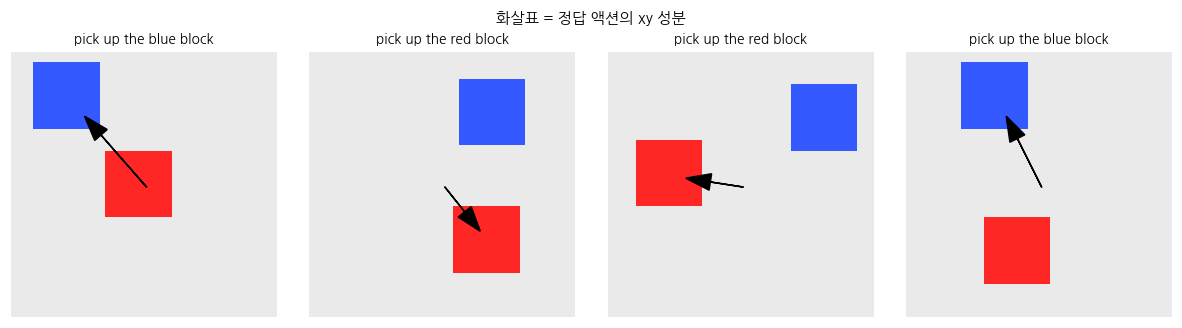

이미지 (4, 3, 48, 48) | 토큰 (4, 5) | 액션 (4, 7)


In [3]:
IMG, PATCH, SQ = 48, 8, 12          # 이미지 48x48, 패치 8 -> 6x6 = 36 토큰
COLORS = {"red": (1., .15, .15), "blue": (.2, .35, 1.)}
NAMES  = list(COLORS)
VOCAB  = ["<pad>", "pick", "up", "the", "block", "red", "blue"]
STOI   = {w: i for i, w in enumerate(VOCAB)}
ADIM   = 7

def make_sample(rng):
    # 책상 한 장면과 그에 대한 (지시문, 정답 액션) 한 쌍을 만든다
    img = np.full((3, IMG, IMG), .92, np.float32)   # 밝은 회색 책상
    placed, centre = [], {}
    for name in NAMES:
        for _ in range(80):                          # 겹치지 않게 배치
            x, y = rng.integers(2, IMG - SQ - 2, 2)
            if all(abs(x-a) > SQ+2 or abs(y-b) > SQ+2 for a, b in placed):
                break
        placed.append((x, y)); centre[name] = (x + SQ/2, y + SQ/2)
        for k in range(3):
            img[k, y:y+SQ, x:x+SQ] = COLORS[name][k]

    target = NAMES[int(rng.integers(len(NAMES)))]
    tokens = [STOI[w] for w in ["pick", "up", "the", target, "block"]]

    # 그리퍼(화면 중앙)에서 목표 블록으로 향하는 delta 액션
    dx = (centre[target][0] - IMG/2) / (IMG/2)
    dy = (centre[target][1] - IMG/2) / (IMG/2)
    dist = math.hypot(dx, dy)
    action = np.array([
        dx, dy,                       # x, y 이동
        -0.15 - 0.5*dist,             # z: 멀수록 크게 하강
        0., 0.,                       # roll, pitch 고정
        math.atan2(dy, dx)/math.pi,   # yaw: 목표 방향
        1. if dist < .4 else -1.      # gripper: 가까우면 닫는다
    ], np.float32)
    return img, np.array(tokens, np.int64), np.clip(action, -1, 1)

def make_dataset(n, seed):
    rng = np.random.default_rng(seed)
    im, tk, ac = zip(*[make_sample(rng) for _ in range(n)])
    return (torch.from_numpy(np.stack(im)),
            torch.from_numpy(np.stack(tk)),
            torch.from_numpy(np.stack(ac)))

def detok(t):  return " ".join(VOCAB[i] for i in t.tolist())

im, tk, ac = make_dataset(4, 1)
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for i, ax in enumerate(axes):
    ax.imshow(im[i].permute(1, 2, 0).numpy()); ax.axis("off")
    ax.arrow(IMG/2, IMG/2, ac[i,0].item()*IMG/2*.8, ac[i,1].item()*IMG/2*.8,
             head_width=3, color="k", length_includes_head=True)
    ax.set_title(detok(tk[i]), fontsize=9)
plt.suptitle("화살표 = 정답 액션의 xy 성분", fontsize=10); plt.tight_layout(); plt.show()
print("이미지", tuple(im.shape), "| 토큰", tuple(tk.shape), "| 액션", tuple(ac.shape))

## 2. 첫 번째 탑 — 비전

비전 탑이 하는 일은 이미지를 **토큰 시퀀스로 바꾸는 것**뿐이다. 224×224 이미지를 16×16 패치 196장으로 자르고 각 패치를 벡터 하나로 만들면, 그 뒤로는 언어 모델과 똑같이 시퀀스를 다루면 된다. VLA가 트랜스포머 한 덩어리로 굴러가는 이유가 여기 있다.

패치 자르기는 stride가 패치 크기와 같은 합성곱 한 번으로 끝난다.

### 위치 정보를 어떻게 넣는가

패치를 시퀀스로 펴는 순간 "어느 위치의 패치였는지"가 사라진다. 조작 과제에서 위치는 정답 그 자체이므로 반드시 되돌려 줘야 한다. 여기서는 학습 없이 바로 쓸 수 있는 2D sin-cos 임베딩을 쓴다. 학습형 위치 임베딩도 흔하지만, 데이터가 적을 때는 고정형이 눈에 띄게 유리하다.

In [4]:
def sincos_2d(dim, grid):
    # 2D sin-cos 위치 임베딩 -> (1, grid*grid, dim)
    yy, xx = np.meshgrid(np.arange(grid), np.arange(grid), indexing="ij")
    out = np.zeros((grid*grid, dim), np.float32)
    q = dim // 4
    w = 1.0 / (10000 ** (np.arange(q) / q))
    for i, v in enumerate([yy.reshape(-1), xx.reshape(-1)]):
        out[:, i*2*q : i*2*q+q]       = np.sin(v[:, None] * w)
        out[:, i*2*q+q : (i+1)*2*q]   = np.cos(v[:, None] * w)
    return torch.from_numpy(out)[None]

class PatchEmbed(nn.Module):
    def __init__(self, dim, img=IMG, patch=PATCH):
        super().__init__()
        self.grid = img // patch
        self.proj = nn.Conv2d(3, dim, patch, patch)
        self.register_buffer("pos", sincos_2d(dim, self.grid))
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2) + self.pos

pe = PatchEmbed(96)
print("48x48, patch 8  ->", tuple(pe(im).shape), f"  ({pe.grid}x{pe.grid} = {pe.grid**2} 토큰)")

pe_real = PatchEmbed(768, img=224, patch=16)          # 실제 VLA 규격
print("224x224, patch 16 ->", tuple(pe_real(torch.zeros(1,3,224,224)).shape),
      f"  ({pe_real.grid}x{pe_real.grid} = {pe_real.grid**2} 토큰)")

48x48, patch 8  -> (4, 36, 96)   (6x6 = 36 토큰)
224x224, patch 16 -> (1, 196, 768)   (14x14 = 196 토큰)


224x224, patch 16 -> (1, 196, 768)   (14x14 = 196 토큰)


### 트랜스포머 블록

세 탑이 모두 같은 블록을 쓴다. Pre-norm 잔차 구조이며, 요즘 표준이다.

In [5]:
class Block(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.n1  = nn.LayerNorm(dim)
        self.att = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.n2  = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, 4*dim), nn.GELU(), nn.Linear(4*dim, dim))
    def forward(self, x, need_weights=False):
        h = self.n1(x)
        out, w = self.att(h, h, h, need_weights=need_weights, average_attn_weights=True)
        x = x + out
        return x + self.mlp(self.n2(x)), w

b = Block(96, 4)
y, _ = b(pe(im))
print("블록 통과 후:", tuple(y.shape), "— 모양은 그대로, 내용만 섞인다")

블록 통과 후: (4, 36, 96) — 모양은 그대로, 내용만 섞인다


## 3. 두 번째 탑 — 언어

로봇 지시문은 웹 텍스트와 성격이 다르다. 짧고, 명령형이고, 어휘가 좁다. `pick`, `place`, `open`, `push` 같은 동사 수십 개와 물체 이름 수백 개면 대부분 덮인다. 그래서 여기서는 어휘 7개짜리 토크나이저로 충분하다.

실제 모델은 이 자리에 Llama-2나 Gemma 같은 사전학습 언어 모델을 쓴다. 그 차이가 3부에서 볼 일반화 성능의 대부분을 만든다. 웹에서 배운 "바나나"라는 단어의 의미가 로봇 데이터에는 없기 때문이다.

In [6]:
class LangTower(nn.Module):
    def __init__(self, dim, heads, layers=1, maxlen=16):
        super().__init__()
        self.emb = nn.Embedding(len(VOCAB), dim)
        self.pos = nn.Parameter(torch.randn(1, maxlen, dim) * .02)
        self.blocks = nn.ModuleList(Block(dim, heads) for _ in range(layers))
    def forward(self, tok):
        x = self.emb(tok) + self.pos[:, :tok.shape[1]]
        for b in self.blocks:
            x, _ = b(x)
        return x

lt = LangTower(96, 4)
print(detok(tk[0]), "->", tuple(lt(tk).shape))

pick up the blue block -> (4, 5, 96)


## 4. 두 탑을 잇는다 — 융합과 FiLM

여기가 이 장의 핵심이고, 이 노트북에서 가장 많이 틀리는 자리다.

가장 단순한 융합은 두 시퀀스를 **이어 붙여 한 시퀀스로 만드는 것**이다. 36개 비전 토큰과 5개 언어 토큰을 concat 하면 41개짜리 시퀀스가 되고, 그 위에서 self-attention을 돌리면 모든 비전 패치가 모든 언어 토큰을 볼 수 있다. 어느 토큰이 어느 모달리티였는지는 모달리티 임베딩으로 알려 준다.

원리적으로는 이것으로 충분하다. 그런데 실제 VLA 개발에서 반복해서 보고되는 실패 양상이 있다. **모델이 언어를 무시한다.** 비전만으로 손실을 어느 정도 줄일 수 있으면 (이 과제에서는 두 블록의 중간 지점을 찍는 것이 그렇다) 경사하강은 굳이 어려운 언어 결합을 배우려 하지 않는다.

그래서 언어를 **비전 특징에 직접 주입하는** 경로를 하나 더 내는 처방이 나왔다. 언어 벡터로 비전 특징의 채널별 스케일과 시프트를 만들어 곱하고 더하는 방식이며 FiLM이라 부른다. 색은 채널에 인코딩돼 있으므로 채널을 조절하는 것만으로 "빨간 것만 보게" 만들 수 있다. **OpenVLA-OFT 논문이 언어 지시 following 문제를 해결하려고 넣은 장치가 정확히 이것이다.** 9장에서 다시 만난다.

여기서는 FiLM을 켜고 끌 수 있게 만들어 둔다. 8절에서 이 과제에 정말 필요한지 직접 재 볼 것이고, 결과는 미리 말해 두자면 교과서적이지 않다.

γ와 β를 만드는 선형층은 0으로 초기화한다. 학습 시작 시점에는 항등 변환이라 FiLM이 방해가 되지 않고, 필요해지면 자라난다.

In [7]:
class MiniVLA(nn.Module):
    def __init__(self, dim=96, heads=4, n_vis=2, n_lang=1, n_fuse=2,
                 adim=ADIM, use_film=True, img=IMG, patch=PATCH):
        super().__init__()
        self.adim, self.use_film = adim, use_film
        # --- 탑 1: 비전 ---
        self.patch_embed = PatchEmbed(dim, img, patch)
        self.vis = nn.ModuleList(Block(dim, heads) for _ in range(n_vis))
        # --- 탑 2: 언어 ---
        self.lang = LangTower(dim, heads, n_lang)
        # --- FiLM: 언어 -> 비전 채널 변조 ---
        if use_film:
            self.lq   = nn.Parameter(torch.randn(1, 1, dim) * .02)      # 풀링 질의
            self.pool = nn.MultiheadAttention(dim, heads, batch_first=True)
            self.film = nn.Linear(dim, 2*dim)
            nn.init.zeros_(self.film.weight); nn.init.zeros_(self.film.bias)
        # --- 융합 백본 ---
        self.modality = nn.Parameter(torch.randn(2, dim) * .02)
        self.fuse = nn.ModuleList(Block(dim, heads) for _ in range(n_fuse))
        self.norm = nn.LayerNorm(dim)
        # --- 탑 3: 액션 디코더 ---
        self.aq   = nn.Parameter(torch.randn(1, adim, dim) * .02)       # 액션 질의 7개
        self.dec  = Block(dim, heads)
        self.head = nn.Linear(dim, 1)                                   # 연속 출력
        self.last_pool_attn = None

    def forward(self, img, tok, drop_lang=False, trace=False):
        shapes = {}
        v = self.patch_embed(img);                shapes["비전 패치 임베딩"] = tuple(v.shape)
        for b in self.vis: v, _ = b(v)
        shapes["비전 탑 출력"] = tuple(v.shape)

        l = self.lang(tok);                       shapes["언어 탑 출력"] = tuple(l.shape)
        if drop_lang:
            l = torch.zeros_like(l)               # 절제 실험: 언어를 끊는다

        if self.use_film:
            pooled, attn = self.pool(self.lq.expand(l.shape[0], -1, -1), l, l,
                                     need_weights=True, average_attn_weights=True)
            self.last_pool_attn = attn.detach()
            gamma, beta = self.film(pooled[:, 0]).chunk(2, -1)
            v = v * (1 + gamma[:, None]) + beta[:, None]
            shapes["FiLM 변조 후 비전"] = tuple(v.shape)

        x = torch.cat([v + self.modality[0], l + self.modality[1]], 1)
        shapes["융합 시퀀스"] = tuple(x.shape)
        for b in self.fuse: x, _ = b(x)
        x = self.norm(x)

        q = self.aq.expand(x.shape[0], -1, -1)
        y, _ = self.dec(torch.cat([x, q], 1))
        a = self.head(y[:, -self.adim:]).squeeze(-1)
        shapes["액션 출력"] = tuple(a.shape)
        return (a, shapes) if trace else a

model = MiniVLA()
n = sum(p.numel() for p in model.parameters())
print(f"미니 VLA 파라미터 {n/1e6:.2f}M")

미니 VLA 파라미터 0.75M


In [8]:
_, shapes = model(im, tk, trace=True)
print(f"{'단계':<22}{'텐서 모양':<20}설명")
print("-"*74)
desc = {"비전 패치 임베딩":"이미지 -> 36 토큰", "비전 탑 출력":"패치끼리 정보 교환",
        "언어 탑 출력":"지시문 5 토큰", "FiLM 변조 후 비전":"언어가 채널을 조절",
        "융합 시퀀스":"36 + 5 = 41 토큰", "액션 출력":"7-DoF"}
for k, v in shapes.items():
    print(f"{k:<22}{str(v):<20}{desc.get(k,'')}")

단계                    텐서 모양               설명
--------------------------------------------------------------------------
비전 패치 임베딩             (4, 36, 96)         이미지 -> 36 토큰
비전 탑 출력               (4, 36, 96)         패치끼리 정보 교환
언어 탑 출력               (4, 5, 96)          지시문 5 토큰
FiLM 변조 후 비전          (4, 36, 96)         언어가 채널을 조절
융합 시퀀스                (4, 41, 96)         36 + 5 = 41 토큰
액션 출력                 (4, 7)              7-DoF


## 5. 세 번째 탑 — 액션 디코더

앞의 두 탑은 다른 분야에서 빌려 온 것이지만, 액션 디코더는 로봇을 위해 새로 붙인 부분이고 VLA 설계에서 가장 논쟁적인 자리다. 선택지는 크게 둘이다.

**이산 방식** — 액션 각 축을 256개 구간으로 나누고 구간 번호를 언어 토큰처럼 예측한다. RT-2와 OpenVLA가 이 방식이다. 언어 모델을 그대로 재활용할 수 있다는 것이 최대 장점이다.

**연속 방식** — 실수 값을 직접 회귀한다. π0의 플로 매칭과 OpenVLA-OFT의 L1 회귀가 여기 속한다.

이 노트북은 연속 방식으로 학습한다. 이산 방식은 같은 규모에서 수렴이 불안정했는데, **그 사실 자체가 5장의 출발점**이다. 이산화 코드는 아래에 같이 둔다.

In [9]:
BINS = 256
def action_to_bins(a, bins=BINS):
    return ((a.clamp(-1, 1) + 1) / 2 * (bins - 1)).round().long()
def bins_to_action(i, bins=BINS):
    return i.float() / (bins - 1) * 2 - 1

a0 = ac[0]
b0 = action_to_bins(a0)
err = (bins_to_action(b0) - a0).abs().max().item()
print("원본 액션 :", np.round(a0.numpy(), 3))
print("구간 번호 :", b0.numpy())
print("복원 액션 :", np.round(bins_to_action(b0).numpy(), 3))
print(f"\n256구간 이산화의 최대 재구성 오차 {err:.5f}  (이론 한계 {1/255:.5f})")
print("이 오차 자체는 작다. 5장에서 볼 문제는 정밀도가 아니라 토큰 길이와 학습 효율이다.")

원본 액션 : [-0.583 -0.667 -0.593  0.     0.    -0.729 -1.   ]
구간 번호 : [ 53  42  52 128 128  35   0]
복원 액션 : [-0.584 -0.671 -0.592  0.004  0.004 -0.725 -1.   ]

256구간 이산화의 최대 재구성 오차 0.00392  (이론 한계 0.00392)
이 오차 자체는 작다. 5장에서 볼 문제는 정밀도가 아니라 토큰 길이와 학습 효율이다.


## 6. 지연 예산 — 어디서 시간이 사라지는가

로봇은 정해진 주기 안에 답을 받아야 한다. 10Hz 제어라면 100ms 안에 forward pass가 끝나야 한다. 그러려면 어느 단계가 얼마를 쓰는지 알아야 한다.

이 측정은 축소 모델이라 절대값은 의미가 없다. 봐야 할 것은 **비율**이다. 실제 7B VLA에서도 융합 백본이 지배적이라는 구조는 그대로다.

단계                  ms       비중
-------------------------------
비전 탑              0.68    40.9%
언어 탑              0.22    13.2%
융합 백본             0.54    32.6%
액션 디코더            0.22    13.4%
-------------------------------
합계                1.66        
제어 주파수 상한 604 Hz


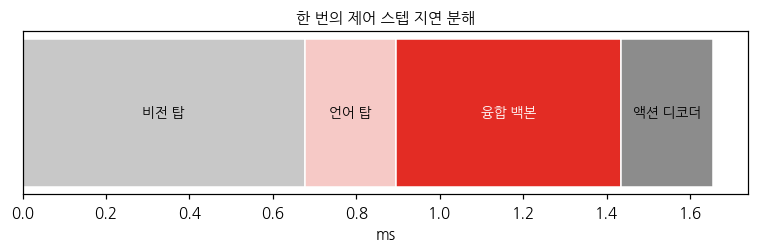

In [10]:
@torch.no_grad()
def stage_latency(m, img, tok, reps=30):
    m.eval()
    def timeit(fn):
        for _ in range(5): fn()
        t = time.perf_counter()
        for _ in range(reps): fn()
        return (time.perf_counter() - t) / reps * 1000
    v = m.patch_embed(img)
    def f_vis():
        x = m.patch_embed(img)
        for b in m.vis: x, _ = b(x)
        return x
    def f_lang():
        return m.lang(tok)
    vv, ll = f_vis(), f_lang()
    def f_fuse():
        x = torch.cat([vv + m.modality[0], ll + m.modality[1]], 1)
        for b in m.fuse: x, _ = b(x)
        return m.norm(x)
    xx = f_fuse()
    def f_act():
        q = m.aq.expand(xx.shape[0], -1, -1)
        y, _ = m.dec(torch.cat([xx, q], 1))
        return m.head(y[:, -m.adim:])
    return {"비전 탑": timeit(f_vis), "언어 탑": timeit(f_lang),
            "융합 백본": timeit(f_fuse), "액션 디코더": timeit(f_act)}

one = (im[:1], tk[:1])
lat = stage_latency(model, *one)
total = sum(lat.values())
print(f"{'단계':<14}{'ms':>8}{'비중':>9}")
print("-"*31)
for k, v in lat.items():
    print(f"{k:<14}{v:8.2f}{v/total*100:8.1f}%")
print("-"*31)
print(f"{'합계':<14}{total:8.2f}{'':>8}\n제어 주파수 상한 {1000/total:.0f} Hz")

fig, ax = plt.subplots(figsize=(7, 2.4))
left = 0
for (k, v), c in zip(lat.items(), ["#c8c8c8", "#f6c9c6", "#e32c24", "#8c8c8c"]):
    ax.barh(0, v, left=left, color=c, edgecolor="white")
    if v/total > .06:
        ax.text(left + v/2, 0, k, ha="center", va="center",
                fontsize=9, color="white" if c == "#e32c24" else "black")
    left += v
ax.set_xlabel("ms"); ax.set_yticks([]); ax.set_title("한 번의 제어 스텝 지연 분해", fontsize=10)
plt.tight_layout(); plt.show()

## 7. 학습

이제 실제로 학습시킨다. CPU 두 코어 기준 2분 안팎이다.

손실 함수를 고르는 데 함정이 하나 있다. OpenVLA-OFT를 따라 L1을 쓰면 이 과제에서 **학습이 실패한다.** roll과 pitch처럼 값이 거의 고정된 축은 금세 정답에 도달하는데, L1의 기울기는 오차가 아무리 작아도 크기가 1로 일정하다. 다 맞힌 축들이 부호만 뒤집히는 잡음 기울기를 계속 흘려보내고, 공유 백본에서 그 잡음이 정작 배워야 할 x·y 신호를 덮는다.

Huber 손실은 오차가 작아지면 기울기도 함께 줄어들어 이 문제가 없다. 실제 로봇 데이터는 모든 축이 고루 변하기 때문에 L1으로도 잘 되지만, 축이 편중된 데이터에서는 이 함정을 기억해 둘 만하다.

학습 (4096, 3, 48, 48) | 검증 (512, 3, 48, 48)
FiLM 있는 모델 학습
  step    0  loss 0.3635      0s
  step  150  loss 0.2586      7s
  step  300  loss 0.1522     13s
  step  450  loss 0.0685     20s
  step  600  loss 0.0206     27s
  step  750  loss 0.0091     34s
  완료 41s


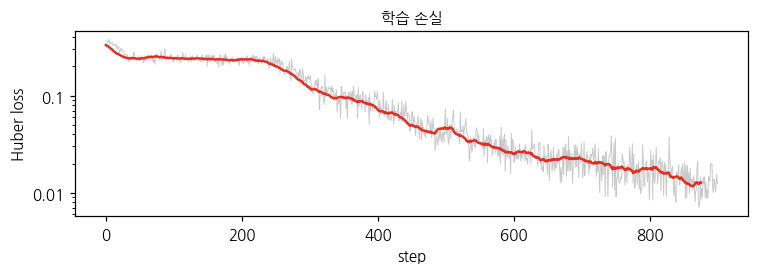

  step  150  loss 0.2412     16s


  step  300  loss 0.1648     33s


  step  450  loss 0.0483     49s


  step  600  loss 0.0242     66s


  step  750  loss 0.0096     83s


  완료 101s


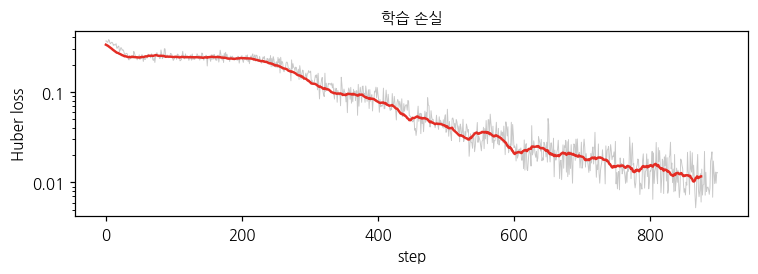

In [11]:
Xi, Xt, Xa = make_dataset(4096, 0)      # 학습
Vi, Vt, Va = make_dataset(512, 99)      # 검증
print("학습", tuple(Xi.shape), "| 검증", tuple(Vi.shape))

def train(use_film=True, steps=900, bs=48, lr=1.5e-3, log=True):
    torch.manual_seed(0)
    m = MiniVLA(use_film=use_film)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=.01)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, steps, pct_start=.15)
    g = torch.Generator().manual_seed(1)
    hist, t0 = [], time.time()
    for i in range(steps):
        idx  = torch.randint(0, len(Xi), (bs,), generator=g)
        loss = F.smooth_l1_loss(m(Xi[idx], Xt[idx]), Xa[idx], beta=0.05)
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
        hist.append(loss.item())
        if log and i % 150 == 0:
            print(f"  step {i:4d}  loss {loss.item():.4f}  {time.time()-t0:5.0f}s")
    if log: print(f"  완료 {time.time()-t0:.0f}s")
    return m, hist

print("FiLM 있는 모델 학습")
model, hist = train(use_film=True)

plt.figure(figsize=(7, 2.6))
plt.plot(hist, lw=.6, color="#c8c8c8")
k = 25; plt.plot(np.convolve(hist, np.ones(k)/k, "valid"), color="#e32c24", lw=1.6)
plt.xlabel("step"); plt.ylabel("Huber loss"); plt.yscale("log")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
plt.gca().yaxis.set_minor_formatter(FuncFormatter(lambda v, _: ""))
plt.title("학습 손실", fontsize=10); plt.tight_layout(); plt.show()

## 8. 언어는 정말 쓰이는가

이 노트북 전체가 이 셀 하나를 위한 것이다.

절제 실험은 간단하다. 학습된 모델을 그대로 두고 **추론할 때만 언어 토큰을 0으로 만든다.** 언어가 실제로 쓰이고 있다면 성능이 무너져야 한다. 무너지지 않는다면 그 모델은 이미지만 보고 답을 찍고 있었던 것이다.

지표는 예측 액션의 xy 성분이 정답 방향과 이루는 **각도 오차**를 쓴다. 방향이 무작위면 평균 90도다.

조건                   MAE      각도오차     30도이내
--------------------------------------------
언어 있음              0.027      4.1°     100%
언어 끊음              0.238     62.5°      51%
--------------------------------------------
언어를 끊자 각도 오차가 15.1배로 늘었다. 언어는 쓰이고 있다.


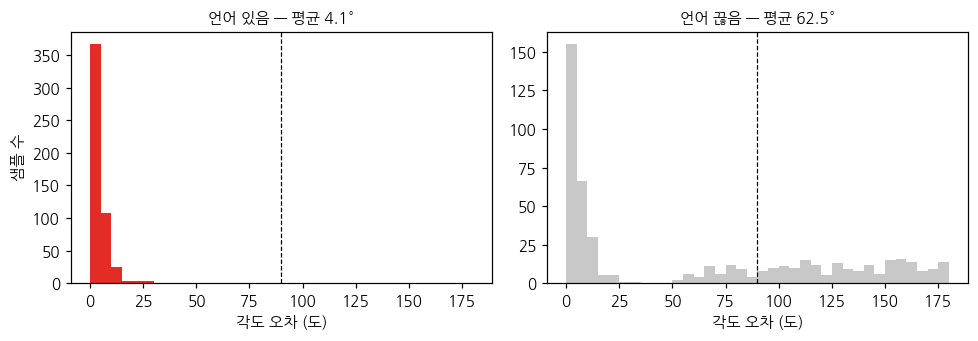

In [12]:
@torch.no_grad()
def evaluate(m, drop_lang=False):
    m.eval()
    p = m(Vi, Vt, drop_lang=drop_lang)
    ang = torch.rad2deg(torch.acos(
        F.cosine_similarity(p[:, :2], Va[:, :2], dim=-1).clamp(-1, 1)))
    return dict(MAE=(p - Va).abs().mean().item(),
                angle=ang.mean().item(),
                acc30=(ang < 30).float().mean().item(), pred=p, ang=ang)

on, off = evaluate(model, False), evaluate(model, True)
print(f"{'조건':<16}{'MAE':>8}{'각도오차':>10}{'30도이내':>10}")
print("-"*44)
print(f"{'언어 있음':<16}{on['MAE']:8.3f}{on['angle']:9.1f}°{on['acc30']:9.0%}")
print(f"{'언어 끊음':<16}{off['MAE']:8.3f}{off['angle']:9.1f}°{off['acc30']:9.0%}")
print("-"*44)
print(f"언어를 끊자 각도 오차가 {off['angle']/on['angle']:.1f}배로 늘었다. 언어는 쓰이고 있다.")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
for a, r, t in zip(ax, [on, off], ["언어 있음", "언어 끊음"]):
    a.hist(r["ang"].numpy(), bins=36, range=(0, 180), color="#e32c24" if t=="언어 있음" else "#c8c8c8")
    a.axvline(90, color="k", ls="--", lw=.8)
    a.set_title(f"{t} — 평균 {r['angle']:.1f}°", fontsize=10)
    a.set_xlabel("각도 오차 (도)")
ax[0].set_ylabel("샘플 수")
plt.tight_layout(); plt.show()

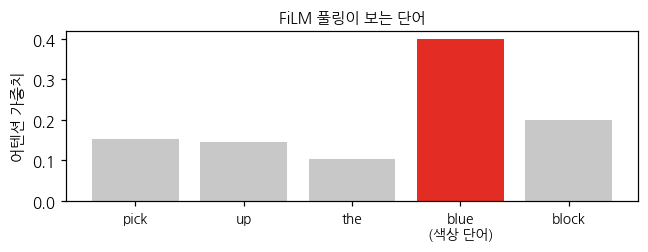

색상 자리 가중치 0.399 / 균등 분포라면 0.200


In [13]:
with torch.no_grad():
    model(Vi[:256], Vt[:256])
    w = model.last_pool_attn[:, 0].mean(0)          # 토큰별 평균 어텐션

words = [VOCAB[i] for i in Vt[0].tolist()]
plt.figure(figsize=(6, 2.4))
bars = plt.bar(range(len(words)), w.numpy(),
               color=["#e32c24" if i == 3 else "#c8c8c8" for i in range(len(words))])
plt.xticks(range(len(words)), [f"{x}\n(색상 단어)" if i == 3 else x
                               for i, x in enumerate(words)], fontsize=9)
plt.ylabel("어텐션 가중치"); plt.title("FiLM 풀링이 보는 단어", fontsize=10)
plt.tight_layout(); plt.show()
print("색상 자리 가중치 %.3f / 균등 분포라면 %.3f" % (w[3].item(), 1/len(words)))

In [14]:
print("FiLM 없는 모델 학습")
model_nofilm, _ = train(use_film=False, log=False)
on2, off2 = evaluate(model_nofilm, False), evaluate(model_nofilm, True)

print(f"\n{'모델':<14}{'언어 있음':>12}{'언어 끊음':>12}{'격차':>9}")
print("-"*47)
for nm, a, b in [("FiLM 있음", on, off), ("FiLM 없음", on2, off2)]:
    print(f"{nm:<14}{a['angle']:11.1f}°{b['angle']:11.1f}°{b['angle']-a['angle']:8.1f}°")
print("-"*47)
print("격차가 클수록 언어에 강하게 의존한다는 뜻이다.")
print()
print("두 모델 모두 언어를 쓰고 있고, 성능 차이는 거의 없다.")
print("이 과제에서 학습을 막고 있던 것은 융합 구조가 아니라 7절의 손실 함수였다.")

FiLM 없는 모델 학습

모델                   언어 있음       언어 끊음       격차
-----------------------------------------------
FiLM 있음               4.1°       62.5°    58.4°
FiLM 없음               3.9°       70.2°    66.3°
-----------------------------------------------
격차가 클수록 언어에 강하게 의존한다는 뜻이다.

두 모델 모두 언어를 쓰고 있고, 성능 차이는 거의 없다.
이 과제에서 학습을 막고 있던 것은 융합 구조가 아니라 7절의 손실 함수였다.



모델                   언어 있음       언어 끊음       격차
-----------------------------------------------
FiLM 있음               4.2°       63.7°    59.5°
FiLM 없음               4.7°       68.9°    64.3°
-----------------------------------------------
격차가 클수록 언어에 강하게 의존한다는 뜻이다.

두 모델 모두 언어를 쓰고 있고, 성능 차이는 거의 없다.
이 과제에서 학습을 막고 있던 것은 융합 구조가 아니라 7절의 손실 함수였다.


### 다음 장으로
이산 방식은 같은 예산에서 수렴하지 못했는데, 그 차이가 어디서 오는지, 256구간 균등 이산화 대신 무엇을 쓰는지가 5장의 주제다. 연속 방식을 제대로 다루는 플로 매칭은 6장에서 만난다.